In [1]:
print('hi')

hi


TensorFlow for CNN  (Convolutional Neural Networks)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models                                  
from tensorflow.keras.datasets import mnist

# load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# reshape for CNN
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# build model
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64,activation='relu'),

    layers.Dense(10,activation='softmax')
])



# compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# train model
model.fit(X_train,y_train,epochs=5)

# evaluate
model.evaluate(X_test,y_test)

c:\Users\EATSK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
 192/1875 ━━━━━━━━━━━━━━━━━━━━ 1:02 37ms/step - accuracy: 0.6817 - loss: 1.0074

In [ ]:
prediction=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [ ]:
import numpy as np
predicted_labels=np.argmax(prediction,axis=1)
print("Predicted:", predicted_labels[6])
print("Actual:", y_test[6])

Predicted: 4
Actual: 4


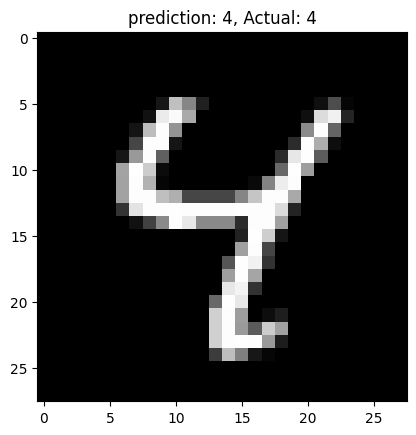

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_test[6].reshape(28,28),cmap='gray')
plt.title(f'prediction: {predicted_labels[6]}, Actual: {y_test[6]}')
plt.show()

In [ ]:
from PIL import Image

img=Image.open('digit.png').convert('L')
img=img.resize((28,28))
img=np.array(img) / 255.0

img=img.reshape(1,28,28,1)

predicted=model.predict(img)
print(np.argmax(predicted))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
7


In [ ]:
from PIL import Image

img = Image.open('digit.png').convert('L')  # grayscale
img = img.resize((28,28))

img = np.array(img) / 255.0
img = img.reshape(1,28,28,1)

prediction = model.predict(img)
print("Predicted digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted digit: 7


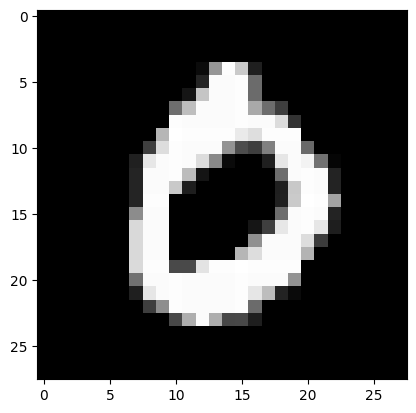

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_test[3].reshape(28,28), cmap='gray')
plt.savefig("digit.png")

In [ ]:
from PIL import Image

img = Image.open('digit.png').convert('L')  # grayscale
img = img.resize((28,28))

img = np.array(img) / 255.0
img = img.reshape(1,28,28,1)

prediction = model.predict(img)
print("Predicted digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted digit: 0


image classification Cat and Dog

In [ ]:
import os
import shutil
import random

source_cats = r"D:\python\python\testing\dataset\test_set\cats"
source_dogs = r"D:\python\python\testing\dataset\test_set\dogs"

base_path = r"D:\python\python\testing\dataset\final"

# create folders
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(base_path, split, "cats"), exist_ok=True)
    os.makedirs(os.path.join(base_path, split, "dogs"), exist_ok=True)

def split_data(source, train_dest, val_dest, test_dest):
    files = os.listdir(source)
    random.shuffle(files)

    total = len(files)
    train_end = int(0.7 * total)
    val_end = int(0.85 * total)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    for f in train_files:
        shutil.copy(os.path.join(source, f), os.path.join(train_dest, f))

    for f in val_files:
        shutil.copy(os.path.join(source, f), os.path.join(val_dest, f))

    for f in test_files:
        shutil.copy(os.path.join(source, f), os.path.join(test_dest, f))


# split cats
split_data(
    source_cats,
    os.path.join(base_path, "train", "cats"),
    os.path.join(base_path, "val", "cats"),
    os.path.join(base_path, "test", "cats")
)

# split dogs
split_data(
    source_dogs,
    os.path.join(base_path, "train", "dogs"),
    os.path.join(base_path, "val", "dogs"),
    os.path.join(base_path, "test", "dogs")
)

print("Dataset split completed")

Dataset split completed


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models

In [ ]:
# This is for Training  Dataset
train_ds=tf.keras.preprocessing.image_dataset_from_directory(
    r'D:\python\python\testing\dataset\final\train',
    image_size=(150,150),
    batch_size=32
)

# This is for Test Dataset
test_ds=tf.keras.preprocessing.image_dataset_from_directory(
    r'D:\python\python\testing\dataset\final\test',
    image_size=(150,150),
    batch_size=32
)

# This is for Validation Dataset
val_ds=tf.keras.preprocessing.image_dataset_from_directory(
    r'D:\python\python\testing\dataset\final\val',
    image_size=(150,150),
    batch_size=32
)

Found 1416 files belonging to 2 classes.
Found 304 files belonging to 2 classes.
Found 303 files belonging to 2 classes.


In [ ]:
# 🔥 SAVE THIS BEFORE .map()
class_names = train_ds.class_names

print(class_names)

['cats', 'dogs']


In [ ]:
temp_ds = tf.keras.preprocessing.image_dataset_from_directory(
    r"D:\python\python\testing\dataset\final\train",
    image_size=(150,150),
    batch_size=32
)

print(temp_ds.class_names)

Found 1416 files belonging to 2 classes.
['cats', 'dogs']


In [ ]:
# normalize

train_ds=train_ds.map(lambda x,y : (x/255.0,y))
test_ds=test_ds.map(lambda x,y : (x/255.0,y))
val_ds=val_ds.map(lambda x,y : (x/255.0,y))


In [ ]:
# create a Model for Image Classifier

model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


model.fit(train_ds,validation_data=val_ds,epochs=10)

model.evaluate(test_ds)
print('model train and test successfully')

Epoch 1/10


c:\Users\EATSK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 504ms/step - accuracy: 0.5148 - loss: 0.7220 - val_accuracy: 0.5314 - val_loss: 0.6882
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 384ms/step - accuracy: 0.5388 - loss: 0.6904 - val_accuracy: 0.5941 - val_loss: 0.6764
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 404ms/step - accuracy: 0.5565 - loss: 0.6804 - val_accuracy: 0.5743 - val_loss: 0.6826
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 385ms/step - accuracy: 0.5614 - loss: 0.6790 - val_accuracy: 0.5875 - val_loss: 0.6757
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 391ms/step - accuracy: 0.6038 - loss: 0.6618 - val_accuracy: 0.5974 - val_loss: 0.6473
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 422ms/step - accuracy: 0.6335 - loss: 0.6415 - val_accuracy: 0.6238 - val_loss: 0.6329
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 392ms/step - accuracy: 0.6843 - loss: 0.5846 - val_accuracy: 0.6370 - val_loss: 0.6514
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 357ms/step - accuracy: 0.7493 - loss: 0.5098 - val_accuracy: 0.693

In [ ]:
# To Process the Image Classifier
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("cat1.jpg", target_size=(150,150))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

if pred[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Dog


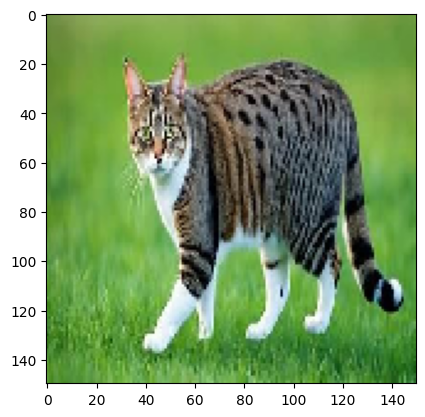

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.show()

In [ ]:
import numpy as np
from keras.losses import binary_crossentropy

# Example true labels and predicted probabilities
y_true = np.array([0, 1, 1, 0, 1])
y_pred = np.array([0.1, 0.9, 0.8, 0.2, 0.7])

# Compute Binary Cross-Entropy using NumPy
def binary_cross_entropy(y_true, y_pred):
    bce = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return bce

bce_loss = binary_cross_entropy(y_true, y_pred)
print(f"Binary Cross-Entropy Loss (manual calculation): {bce_loss}")

# Compute Binary Cross-Entropy using Keras
bce_loss_keras = binary_crossentropy(y_true, y_pred).numpy()
print(f"Binary Cross-Entropy Loss (Keras): {bce_loss_keras}")

Binary Cross-Entropy Loss (manual calculation): 0.20273661557656092
Binary Cross-Entropy Loss (Keras): 0.20273661557656092


This is full animal dataset program 

In [ ]:
import os
import shutil
import random


# 🔹 Source folder (your dataset)
source_dri = r'D:\python\python\testing\dataset\Animal\raw-img'

# 🔹 Destination folder (new split dataset)
base_dri = r'D:\python\python\testing\dataset\Animal\split_data'


# 🔹 Split ratio

train_ratio = 0.7

val_ratio = 0.15

test_ratio = 0.15

# 🔹 Create folders
for split in ['train','val','test']:
  for category in os.listdir(source_dri):
    os.makedirs(os.path.join(base_dri,split,category ),exist_ok=True)



# 🔹 Function to split data
def split_data(category):

  category_path=os.path.join(source_dri,category)
  files=os.listdir(category_path)


  # remove non-image files (important)

  files=[f for f in files if os.path.isfile(os.path.join(category_path,f))]

  # shuffle files randomly
  random.shuffle(files)

  total = len(files)

  train_end = int(total * train_ratio)

  val_end = int(total * (train_ratio + val_ratio))


  train_files = files[:train_end]

  val_files = files[train_end:val_end]

  test_files = files[val_end:]

  # copy files

  for file in train_files:
    shutil.copy(os.path.join(category_path,file),
                os.path.join(base_dri, "train",category,file))

  for file in val_files:
    shutil.copy(os.path.join(category_path,file),
                os.path.join(base_dri, "val",category,file))

  for file in test_files:
    shutil.copy(os.path.join(category_path,file),
                os.path.join(base_dri, "test",category,file))
    

for category in os.listdir(source_dri):
  split_data(category)


print('Dataset successfully split!')

Dataset successfully split!


In [ ]:

import tensorflow as tf
from tensorflow.keras import layers,models


train_ds=tf.keras.preprocessing.image_dataset_from_directory(
    r'D:\python\python\testing\dataset\Animal\split_data\train',
    image_size=(150,150),
    batch_size=32
)

val_ds=tf.keras.preprocessing.image_dataset_from_directory(
    r'D:\python\python\testing\dataset\Animal\split_data\val',
    image_size=(150,150),
    batch_size=32
)

test_ds=tf.keras.preprocessing.image_dataset_from_directory(
    r'D:\python\python\testing\dataset\Animal\split_data\test',
    image_size=(150,150),
    batch_size=32
)

Found 18147 files belonging to 10 classes.
Found 3889 files belonging to 10 classes.
Found 3894 files belonging to 10 classes.


In [ ]:
calss_name=train_ds.class_names
calss_name

train_ds=train_ds.map( lambda x,y: ( x/255.0, y))
val_ds=val_ds.map( lambda x,y: ( x/255.0, y))
test_ds=test_ds.map( lambda x,y: ( x/255.0, y))


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])




num_classes = len(calss_name)

In [ ]:

model = models.Sequential([
    data_augmentation,

    #block1
    layers.Conv2D(32, (3,3),activation='relu',input_shape=(150,150,3)),
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    #block2
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    # block
    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

     # Classifier
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    # Output (Multi-class)
    layers.Dense(num_classes,activation='softmax')

])


#model complie
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


#model training
model.fit(train_ds,validation_data=val_ds,epochs=20)

#model testing
model.evaluate(test_ds)



Epoch 1/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 982s 2s/step - accuracy: 0.2132 - loss: 2.1662 - val_accuracy: 0.3078 - val_loss: 1.9957
Epoch 2/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 641s 1s/step - accuracy: 0.2932 - loss: 1.9904 - val_accuracy: 0.2988 - val_loss: 2.0414
Epoch 3/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 510s 898ms/step - accuracy: 0.3623 - loss: 1.8284 - val_accuracy: 0.3849 - val_loss: 1.7838
Epoch 4/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 503s 884ms/step - accuracy: 0.4183 - loss: 1.6725 - val_accuracy: 0.4466 - val_loss: 1.6438
Epoch 5/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 7167s 13s/step - accuracy: 0.4597 - loss: 1.5567 - val_accuracy: 0.5418 - val_loss: 1.3577
Epoch 6/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 500s 880ms/step - accuracy: 0.4942 - loss: 1.4738 - val_accuracy: 0.5356 - val_loss: 1.3545
Epoch 7/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1287s 2s/step - accuracy: 0.5166 - loss: 1.3945 - val_accuracy: 0.5665 - val_loss: 1.3049
Epoch 8/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1843s 3s/step - accuracy: 0.5345 - loss: 1.35

[1.0666130781173706, 0.6484335064888]

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img('elephant.jpeg',target_size=(150,150))

img_array=image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array,axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

print("Predicted index:", predicted_index)

print("Predicted animal:", calss_name[predicted_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted index: 2
Predicted animal: elefante


In [ ]:
print('hi')

hi


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,datasets
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
(X_train,y_train),(X_test,y_test) = datasets.mnist.load_data()

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
print(f'X_train: {X_train.shape}, x_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), x_test: (10000, 28, 28), y_train: (60000,), y_test: (10000,)


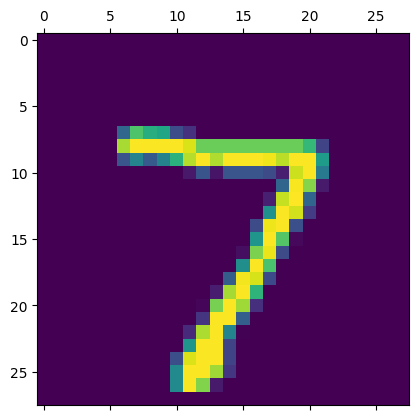

In [ ]:
plt.matshow(X_test[0])

In [ ]:
X_train=X_train/255
X_test=X_test/255

In [ ]:
X_train=X_train.reshape(len(X_train),28 * 28)
X_test=X_test.reshape(len(X_test),28 * 28)

In [ ]:
model=tf.keras.Sequential([
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train,y_train,epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9252 - loss: 0.2605
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9668 - loss: 0.1124
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9767 - loss: 0.0778
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9823 - loss: 0.0584
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9858 - loss: 0.0456


In [ ]:
X_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:

model.evaluate(X_test)

ValueError: None values not supported.

In [ ]:
s='hello'
s[0]='H'
print(s)

TypeError: 'str' object does not support item assignment

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models,datasets
import numpy as np

In [ ]:
(x_train,y_train), (x_test,y_test) =datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
model = tf.keras.Sequential ([
    layers.Flatten(input_shape=(28,28)),

    layers.Dense(128,activation='relu'),

    layers.Dense(10,activation='sigmoid')
])

the_callback = tf.keras.callbacks.TensorBoard(log_dir= 'testing/tensorvisual',histogram_freq=1)

model.compile  (
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.fit(x_train,y_train,epochs=10,callbacks=[the_callback])
model.evaluate(x_test,y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9247 - loss: 0.2637
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9663 - loss: 0.1152
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9752 - loss: 0.0808
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9815 - loss: 0.0597
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9852 - loss: 0.0467
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9887 - loss: 0.0364
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9906 - loss: 0.0300
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9924 - loss: 0.0241
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9939 - loss: 0.0193
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9949 - loss: 0.0169
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9775 - loss: 0.0785


[0.07854197919368744, 0.9775000214576721]

In [ ]:
(x_train,y_train), (x_test,y_test) =datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
y_train_categorical  = tf.keras.utils.to_categorical(y_train,num_classes=10)

y_test_categorical = tf.keras.utils.to_categorical(y_test,num_classes=10)

In [ ]:
model = tf.keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),

    layers.Dense(128,activation="relu"),

    layers.Dense(10,activation='sigmoid')
])

model.compile(
    optimizer ='sgd',
    loss ='categorical_crossentropy',
    metrics=['accuracy']
)



c:\Users\EATSK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(x_train,y_train_categorical,epochs=200)

Epoch 1/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3263 - loss: 1.8915
Epoch 2/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3965 - loss: 1.7217
Epoch 3/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4222 - loss: 1.6440
Epoch 4/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4404 - loss: 1.5934
Epoch 5/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4544 - loss: 1.5507
Epoch 6/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4678 - loss: 1.5175
Epoch 7/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4758 - loss: 1.4919
Epoch 8/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4859 - loss: 1.4668
Epoch 9/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4889 - loss: 1.4455
Epoch 10/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4979 - loss: 1.4262
Epoch 11/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5056 - loss: 1.4080
Epoch 12/200
1563/1

In [ ]:
model.evaluate(x_test,y_test_categorical)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4814 - loss: 2.0389


[2.038926362991333, 0.4814000129699707]

In [ ]:
class_lable= ['airplane','automobile','bird',"cat",'deer','dog','frog','horse',	'ship',	'truck']

In [ ]:
model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[2.2836594e-02, 6.2378865e-01, 9.7704881e-01, ..., 1.3747666e-02,
        3.8942194e-01, 4.0198155e-02],
       [6.0658354e-01, 9.9995208e-01, 4.4601187e-02, ..., 3.2661259e-02,
        9.9989522e-01, 9.9998635e-01],
       [9.9534464e-01, 9.8739731e-01, 9.5874488e-01, ..., 6.7247391e-02,
        9.9848539e-01, 9.9403697e-01],
       ...,
       [9.6164161e-01, 7.9406839e-04, 9.9810386e-01, ..., 4.3964845e-01,
        9.9930453e-01, 1.4481602e-02],
       [8.1036198e-01, 9.2082763e-01, 4.1948727e-01, ..., 7.0816487e-01,
        6.5766230e-02, 9.7054631e-02],
       [7.1640082e-02, 5.4541957e-01, 4.4546264e-01, ..., 9.9675840e-01,
        1.1737244e-01, 1.3444841e-01]], dtype=float32)

In [ ]:
class_lable[y_test[0][0]]

'cat'

In [ ]:
np.argmax(model.predict(x_test)[3])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


8

In [ ]:
class_lable[y_test[3][0]]

'airplane'

In [ ]:
model = tf.keras.Sequential([

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(10,activation='sigmoid')
])

model.compile(
    optimizer ='adam',
    loss ='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train,y_train_categorical,epochs=50)


Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4852 - loss: 1.4758
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5812 - loss: 1.2108
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6184 - loss: 1.1061
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6425 - loss: 1.0385
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.6620 - loss: 0.9844
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.6757 - loss: 0.9410
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6862 - loss: 0.9102
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6952 - loss: 0.8832
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7059 - loss: 0.8573
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7141 - loss: 0.8324
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.7176 - loss: 0.8142
Epoch 12/50
1563/15

In [ ]:
model.evaluate(x_test,y_test_categorical)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6125 - loss: 1.5834


[1.5834299325942993, 0.612500011920929]

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img('cat1.jpg',target_size=(32,32))

img_array=image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array,axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

print("Predicted index:", predicted_index)

print("Predicted animal:", class_lable[predicted_index])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted index: 1
Predicted animal: automobile


In [ ]:
prediction = model.predict(y_test_categorical[1])

predicted_index = np.argmax(prediction)

print("Predicted index:", predicted_index)

print("Predicted animal:", class_lable[predicted_index])

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
import tensorflow as tf



ImportError: cannot import name 'dataset' from 'tensorflow.keras' (c:\Users\EATSK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\_tf_keras\keras\__init__.py)

In [ ]:
!pip uninstall tensorflow
print('success')

^C
success


In [ ]:
print('hi')

hi


In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers

In [ ]:
(x_train,y_train),(x_test,y_test) = datasets.cifar10.load_data()

In [ ]:
print(f'{x_train.shape}, {x_test.shape}')
print(f'{y_train.shape}, {y_test.shape}')

(50000, 32, 32, 3), (10000, 32, 32, 3)
(50000, 1), (10000, 1)


In [ ]:
x_train_scale = x_train / 255.0
x_test_scale = x_test / 255.0


In [ ]:
model = tf.keras.Sequential([
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Flatten(),

    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics =['accuracy']
)




c:\Users\EATSK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(x_train_scale,y_train,epochs=20)

Epoch 1/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.3816 - loss: 1.6846
Epoch 2/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.5047 - loss: 1.3756
Epoch 3/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5500 - loss: 1.2602
Epoch 4/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.5823 - loss: 1.1730
Epoch 5/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6005 - loss: 1.1221
Epoch 6/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6169 - loss: 1.0785
Epoch 7/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6310 - loss: 1.0320
Epoch 8/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6439 - loss: 0.9945
Epoch 9/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6538 - loss: 0.9776
Epoch 10/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6627 - loss: 0.9464
Epoch 11/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6696 - loss: 0.91

KeyboardInterrupt: 

In [ ]:
model.evaluate(x_test_scale,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6991 - loss: 1.1341


[1.1340923309326172, 0.6991000175476074]

In [ ]:
class_names = ['airplane','automobile','bird','cat','dog',
               'frog','horse','ship','truck']

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img('car.jpeg', target_size=(32,32))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)
class_index = np.argmax(prediction)
print(class_names[class_index])


NameError: name 'model' is not defined

In [ ]:
import numpy as np

index = 0  # try different values later

image = x_test[3]
label = y_test[3]

prediction = model.predict(image.reshape(1,32,32,3))
predicted_class = np.argmax(prediction)


print("Predicted:", predicted_class)
print("Actual:", label)

class_names = [
 'airplane','automobile','bird','cat',
 'deer','dog','frog','horse','ship','truck'
]

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[int(label)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
Predicted: 0
Actual: [0]
Predicted: airplane
Actual: airplane


C:\Users\EATSK\AppData\Local\Temp\ipykernel_18308\3136786451.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Actual:", class_names[int(label)])


this is all vehical models it is use to decited the which vehical

In [ ]:
class_name =list()


In [ ]:
import os
import shutil
import random

# INPUT (original dataset)
input_dir = r"D:\python\python\testing\dataset\vehical\vehicle_data"

# OUTPUT (split dataset)
output_dir = r"D:\python\python\testing\dataset\vehical\vehical_splited_data"

train_ratio = 0.7
test_ratio = 0.15
val_ratio = 0.15

classes = os.listdir(input_dir)

for cls in classes:
    cls_path = os.path.join(input_dir,cls)

    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)
    random.shuffle(images)

    total = len(images)

    train_end = int(total * train_ratio)
    val_end = int(total * (train_ratio + val_ratio))

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for split in ['train','test','val']:
        os.makedirs(os.path.join(output_dir,split,cls),exist_ok=True)

    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_path,img),
            os.path.join(output_dir,'train',cls,img)
            )
    
    for img in test_imgs:
        shutil.copy(
            os.path.join(cls_path,img),
            os.path.join(output_dir,'test',cls,img)
        )
    
    for img in val_imgs:
        shutil.copy(
            os.path.join(cls_path,img),
            os.path.join(output_dir,'val',cls,img)
        )


print("Dataset split completed successfully!")

Dataset split completed successfully!


In [ ]:
print(0.15*100)

15.0


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

In [3]:
import tensorflow as tf

train_dir = r"D:\python\python\testing\dataset\vehical\vehical_splited_data\train"
val_dir = r"D:\python\python\testing\dataset\vehical\vehical_splited_data\val"
test_dir = r"D:\python\python\testing\dataset\vehical\vehical_splited_data\test"



train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(150,150),
    batch_size=32,
    color_mode="rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(150,150),
    batch_size=32,
    color_mode="rgb"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(150,150),
    batch_size=32,
    shuffle=False,
    color_mode="rgb"
)

Found 2571 files belonging to 20 classes.
Found 556 files belonging to 20 classes.
Found 565 files belonging to 20 classes.


In [4]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Total Classes:", num_classes)

Classes: ['airplane', 'ambulance', 'bicycle', 'bike', 'boat', 'bus', 'car', 'fire_truck', 'helicopter', 'hovercraft', 'jet_ski', 'kayak', 'rickshaw', 'scooter', 'segway', 'skateboard', 'tractor', 'truck', 'unicycle', 'van']
Total Classes: 20


In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x,y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x,y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:
print(class_names)

['airplane', 'ambulance', 'bicycle', 'bike', 'boat', 'bus', 'car', 'fire_truck', 'helicopter', 'hovercraft', 'jet_ski', 'kayak', 'rickshaw', 'scooter', 'segway', 'skateboard', 'tractor', 'truck', 'unicycle', 'van']


In [6]:
import os

for cls in class_names:
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(cls, count)

airplane 121
ambulance 126
bicycle 125
bike 134
boat 133
bus 128
car 130
fire_truck 128
helicopter 128
hovercraft 128
jet_ski 130
kayak 133
rickshaw 128
scooter 135
segway 130
skateboard 131
tractor 135
truck 118
unicycle 123
van 132


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

this is error 

In [ ]:
model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # ✅ FIXED HERE
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15


81/81 ━━━━━━━━━━━━━━━━━━━━ 41s 506ms/step - accuracy: 0.0712 - loss: 2.9931 - val_accuracy: 0.1079 - val_loss: 2.9471
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 36s 442ms/step - accuracy: 0.1070 - loss: 2.9000 - val_accuracy: 0.1475 - val_loss: 2.9066
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 35s 438ms/step - accuracy: 0.1497 - loss: 2.7861 - val_accuracy: 0.2194 - val_loss: 2.6791
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 36s 443ms/step - accuracy: 0.1774 - loss: 2.6810 - val_accuracy: 0.2302 - val_loss: 2.5680
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 36s 440ms/step - accuracy: 0.2050 - loss: 2.5676 - val_accuracy: 0.2626 - val_loss: 2.3818
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 452ms/step - accuracy: 0.2310 - loss: 2.4754 - val_accuracy: 0.3453 - val_loss: 2.2413
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 35s 434ms/step - accuracy: 0.2489 - loss: 2.4164 - val_accuracy: 0.3417 - val_loss: 2.1751
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.2875 - loss: 2.3455

KeyboardInterrupt: 

This is the correct model

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(150,150,3),
    include_top=False,
    weights='imagenet'
)

# freeze base model
base_model.trainable = False

C:\Users\EATSK\AppData\Local\Temp\ipykernel_6436\283290651.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 47s 414ms/step - accuracy: 0.2155 - loss: 2.6249 - val_accuracy: 0.5719 - val_loss: 1.6188
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 360ms/step - accuracy: 0.4247 - loss: 1.8474 - val_accuracy: 0.6960 - val_loss: 1.0941
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 363ms/step - accuracy: 0.5045 - loss: 1.5583 - val_accuracy: 0.7158 - val_loss: 0.9574
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 366ms/step - accuracy: 0.5445 - loss: 1.4309 - val_accuracy: 0.7284 - val_loss: 0.9106
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 375ms/step - accuracy: 0.5819 - loss: 1.3173 - val_accuracy: 0.7356 - val_loss: 0.8808
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 373ms/step - accuracy: 0.6060 - loss: 1.2401 - val_accuracy: 0.7140 - val_loss: 0.8601
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 48s 600ms/step - accuracy: 0.6223 - loss: 1.1992 - val_accuracy: 0.7086 - val_loss: 0.8536
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 32s 396ms/step - accuracy: 0.6340 - loss: 1.1437 - val_accu

In [ ]:
model.evaluate(test_ds)

18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 557ms/step - accuracy: 0.7575 - loss: 0.7852


[0.785159707069397, 0.7575221061706543]

base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=val_ds, epochs=5)

In [ ]:
model.save("vehicle_model.h5")

In [7]:
from tensorflow.keras.models import load_model

model = load_model("vehicle_model.h5")

In [8]:
import json

with open("classes.json", "w") as f:
    json.dump(class_names, f)

In [9]:
with open("classes.json", "r") as f:
    class_names = json.load(f)

In [10]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = r"D:\python\python\testing\airplane.jpg"

# load image
img = image.load_img(img_path, target_size=(150,150))

# convert to array
img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# prediction
predictions = model.predict(img_array)

# get highest probability class
predicted_class = class_names[np.argmax(predictions)]

print("Prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction: helicopter


In [11]:
confidence = np.max(predictions)
print("Confidence:", confidence)

Confidence: 0.5530708


In [ ]:
from PIL import Image
import os

def convert_to_rgb(folder):
    fixed = 0
    removed = 0

    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)

            try:
                img = Image.open(path)

                # Convert everything to RGB
                if img.mode != "RGB":
                    img = img.convert("RGB")
                    img.save(path)
                    fixed += 1

            except:
                # remove corrupted image
                print("❌ Removing:", path)
                os.remove(path)
                removed += 1

    print("✅ Converted:", fixed)
    print("❌ Removed:", removed)


convert_to_rgb(r"D:\python\python\testing\dataset\vehical\vehical_splited_data")

c:\Users\EATSK\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


✅ Converted: 311
❌ Removed: 0


In [ ]:
for images, labels in train_ds.take(1):
    print(images.shape)

(32, 150, 150, 3)


my image project

In [ ]:
import cv2

cv2.imread("E:\old memories\IMG_20200101_120106.jpg")

array([[[253, 253, 253],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [253, 253, 253],
        [253, 253, 253],
        [253, 253, 253]],

       [[253, 253, 253],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [253, 253, 253],
        [253, 253, 253],
        [253, 253, 253]],

       [[253, 253, 253],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [253, 253, 253],
        [253, 253, 253],
        [253, 253, 253]],

       ...,

       [[ 90,  65, 203],
        [121,  96, 234],
        [126, 101, 239],
        ...,
        [100,  95,  86],
        [100,  95,  86],
        [ 95,  90,  81]],

       [[ 92,  67, 205],
        [118,  93, 231],
        [126, 101, 239],
        ...,
        [105,  98,  89],
        [ 98,  91,  82],
        [102,  95,  86]],

       [[100,  75, 213],
        [ 94,  69, 207],
        [110,  85, 223],
        ...,
        [100,  93,  84],
        [102,  95,  86],
        [100,  93,  84]]